# Project : Car Price Prediction

## 1. Import Libraries :-

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import warnings
warnings.filterwarnings('ignore')

## 2. Load Dataset :-

In [2]:
df = pd.read_csv("car_data.csv")
df

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


## 3. Explore dataset :-

In [3]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [4]:
df.tail()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
296,city,2016,9.50,11.6,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.9,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.0,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.5,9000,Diesel,Dealer,Manual,0
300,brio,2016,5.30,5.9,5464,Petrol,Dealer,Manual,0


In [5]:
print(f"dataset contain {df.shape[0]} Rows and {df.shape[1]} Columns")

dataset contain 301 Rows and 9 Columns


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Selling_type   301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 21.3 KB


In [7]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


## 4. Data Cleaning :-

In [8]:
# check null values per columns
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(2)

In [10]:
# check Duplicate values
df[df.duplicated()]

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
17,ertiga,2016,7.75,10.79,43000,Diesel,Dealer,Manual,0
93,fortuner,2015,23.00,30.61,40000,Diesel,Dealer,Automatic,0


In [11]:
df['Car_Name'].value_counts()

Car_Name
city                   26
corolla altis          16
verna                  14
fortuner               11
brio                   10
                       ..
Hero Super Splendor     1
Hero Hunk               1
Hero  Ignitor Disc      1
Hero  CBZ Xtreme        1
Bajaj  ct 100           1
Name: count, Length: 98, dtype: int64

In [12]:
#now we drop duplicate values
df = df.drop_duplicates()

In [13]:
df.shape  # 2 duplicate values deleted

(299, 9)

In [14]:
len(df['Car_Name'].value_counts())
df=df.drop('Car_Name',axis=1)

The Car_Name column contain 98 unique values, which would create many additional columns if one-hot encoded. Since the dataset is relatively small and the car name is not essential of predicting price in this project , the column is removed to reduce model complexity.

In [15]:
current_year = 2026
df['Car_Age'] = df['Year'].apply(lambda x: current_year-x)

In [16]:
df = df.drop('Year',axis=1)
df.head()

,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,12


In [17]:
#check categorical values
df['Fuel_Type'].value_counts()

Fuel_Type
Petrol    239
Diesel     58
CNG         2
Name: count, dtype: int64

In [18]:
df['Selling_type'].value_counts()

Selling_type
Dealer        193
Individual    106
Name: count, dtype: int64

In [19]:
df['Transmission'].value_counts()

Transmission
Manual       260
Automatic     39
Name: count, dtype: int64

# 5. Exploratory Data Analysis (EDA) :-

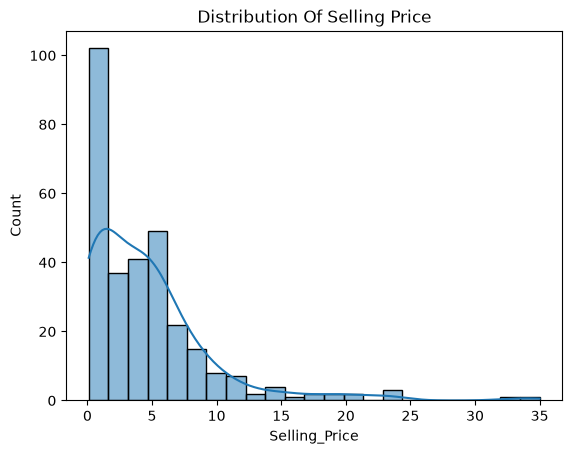

In [20]:
sns.histplot(df['Selling_Price'],kde=True)
plt.title("Distribution Of Selling Price")
plt.show()

insight : 
The selling price are not uniformely distributed. Most cars are sold in the lower price range, while only a few cars have high selling prices.

### 5.2 Present Price vs Selling Price(Regression Plot)

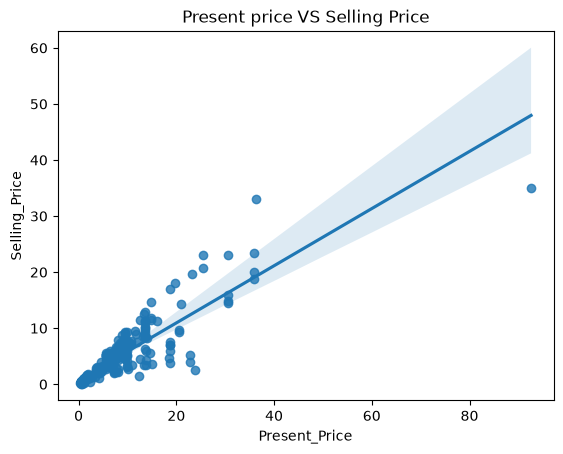

In [21]:
sns.regplot(x="Present_Price",
            y= "Selling_Price",
            data = df)
plt.title("Present price VS Selling Price")
plt.show()

insight :
There is a strong positive relationship between Present Price and Selling Price. Cars with a higher present market price generally have a higher selling price.

### 5.3 Car Age VS Selling Price

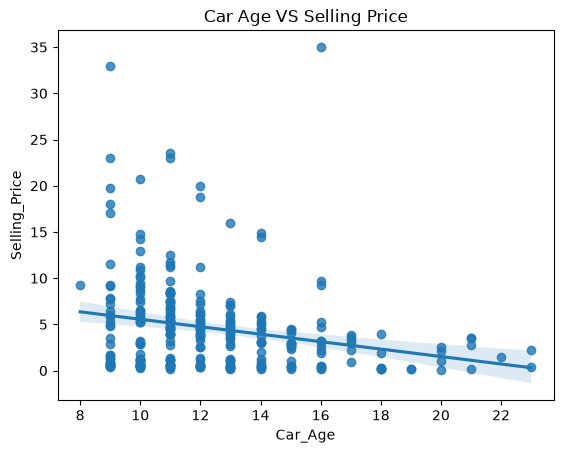

In [22]:
sns.regplot(x="Car_Age",
            y="Selling_Price",
            data = df)
plt.title("Car Age VS Selling Price")
plt.show()

insight :
car Age has a negative relationship with selling price. Older age cars generally have a lower selling price.

### 5.4 Kilometer Driven vs Selling Price

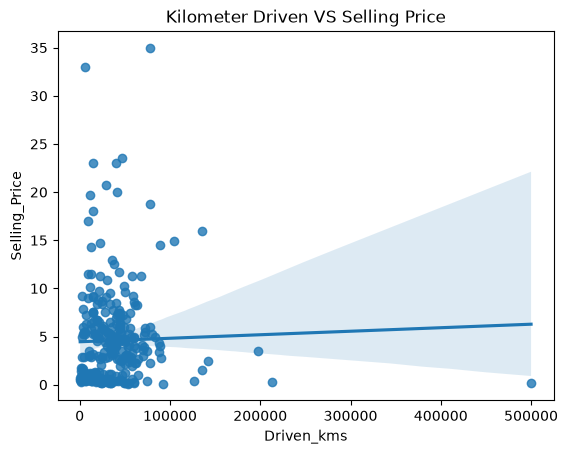

In [23]:
sns.regplot(x="Driven_kms",
            y="Selling_Price",
            data = df)
plt.title("Kilometer Driven VS Selling Price")
plt.show()

Insight:

Kilometers Driven has a weak relationship with Selling Price. Cars with higher mileage tend to have lower selling prices, but the relationship is not very strong due to high variation in the data.

### 5.5 Fuel Type VS Selling Price

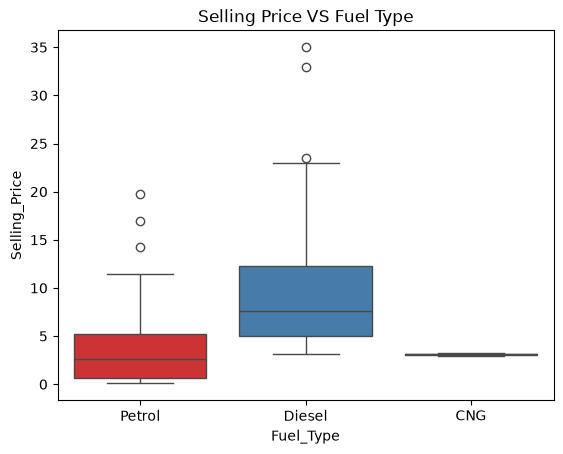

In [24]:
sns.boxplot(x='Fuel_Type',
            y="Selling_Price",
            data = df,
            palette = "Set1")
plt.title("Selling Price VS Fuel Type")
plt.show()

Insight:

Diesel cars generally have a higher selling price than Petrol and CNG cars. CNG cars are very few in the dataset, so conclusions about them are limited.

### 5.7 Transmission VS Selling Price

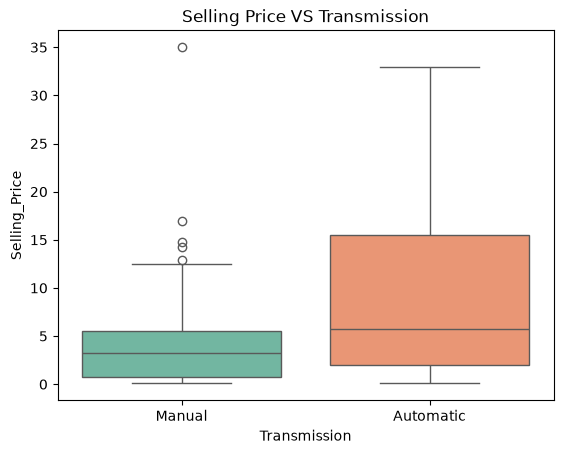

In [25]:
sns.boxplot(x= 'Transmission',
            y='Selling_Price',
            data = df,
            palette="Set2")
plt.title("Selling Price VS Transmission")
plt.show()

Insight:

Automatic transmission cars generally have a higher selling price than manual transmission cars.

### 5.8 Owner VS Selling price

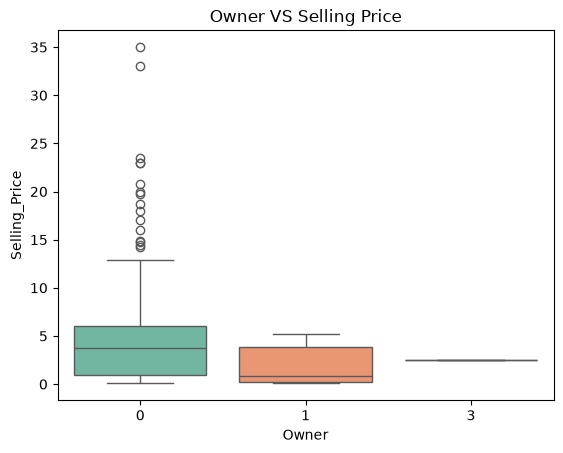

In [26]:
sns.boxplot(x= 'Owner',
            y='Selling_Price',
            data = df,
            palette="Set2")
plt.title("Owner VS Selling Price")
plt.show()

insight :
Cars with fewer previous owners tend to have higher selling prices. Cars with multiple previous owner generally have lower resale value.

## 6. Feature Engineering:-

### 6.1 Encode Categorical Values 

In [27]:
df.head()

,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,12


In [28]:
df = pd.get_dummies(df,
                    columns= ["Fuel_Type","Selling_type","Transmission"],
                    drop_first=True,dtype=int)

In [29]:
df.head()

,Selling_Price,Present_Price,Driven_kms,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,12,0,1,0,1
1,4.75,9.54,43000,0,13,1,0,0,1
2,7.25,9.85,6900,0,9,0,1,0,1
3,2.85,4.15,5200,0,15,0,1,0,1
4,4.60,6.87,42450,0,12,1,0,0,1



One-Hot Encoding converts categorical variables into numerical format so machine learning models can process them.

## 7. Define Features and Target:-

In [30]:
features = df.drop("Selling_Price",axis =1)
target = df["Selling_Price"]

## 8. Train-Test-Split :-

In [31]:
features_train, features_test, target_train, target_test = train_test_split(features,
                                                                            target,
                                                                            test_size=0.2,
                                                                            random_state=42)

## 9. Feature Scaling :-

In [32]:
scalar = StandardScaler()
features_train_scaled = scalar.fit_transform(features_train)
features_test_scaled = scalar.transform(features_test)

## 10. Train The Linear Regression Model :-

In [33]:
lr = LinearRegression()
lr.fit(features_train_scaled,target_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ 3.85,-0.3 , 0.11,..., 0.27,-0.62,-0.53]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.584
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](8,)","[26.23,19.34,15.92,..., 9.91, 8.6 , 1.79]"


### 10.1 Prediction

In [34]:
target_predict_lr = lr.predict(features_test_scaled)

### 10.2 Model Evaluation

In [35]:
mse = mean_squared_error(target_test,target_predict_lr)
mae = mean_absolute_error(target_test,target_predict_lr)
rmse = np.sqrt(mse)
r2 = r2_score(target_test,target_predict_lr)
print("MAE : ",mae)
print("MSE : ",mse)
print("RMSE : ",rmse)
print("R2 Score : ",r2)


MAE :  1.4725457508178565
MSE :  6.373125106260672
RMSE :  2.524504923001869
R2 Score :  0.75272338242205


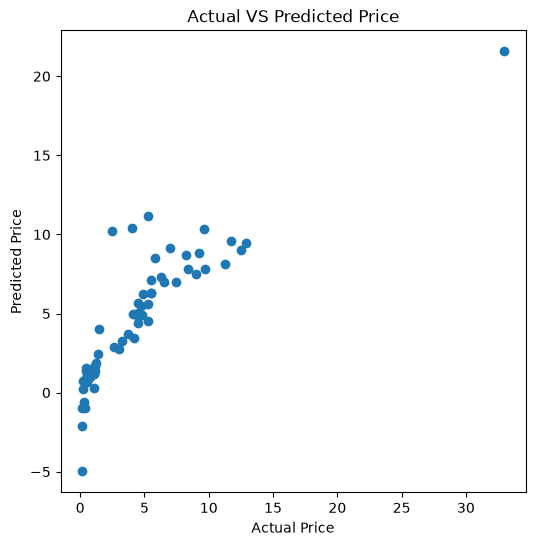

In [36]:
plt.figure(figsize=(6,6))
plt.scatter(target_test,target_predict_lr)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual VS Predicted Price")
plt.show()

Linear Regression achieved an R² score of 0.75, indicating that the model explains about 75% of the variance in selling price. The model performs reasonably well but there is still room for improvement using more advanced regression algorithms.

## 11. Decision Tree Regressor

In [37]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(features_train,target_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes 

### 11.1 Predict

In [38]:
target_predict_dt = dt.predict(features_test)

### 11.2 Evaluation

In [39]:
mae_dt = mean_absolute_error(target_test, target_predict_dt)
mse_dt = mean_squared_error(target_test, target_predict_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(target_test, target_predict_dt)

print("MAE :", mae_dt)
print("MSE :", mse_dt)
print("RMSE :", rmse_dt)
print("R2 Score :", r2_dt)

MAE : 1.1085
MSE : 4.433641666666667
RMSE : 2.1056214442930306
R2 Score : 0.8279751461635348


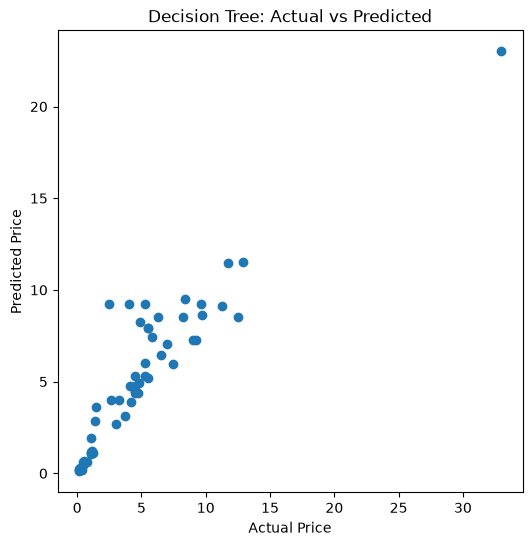

In [40]:
plt.figure(figsize=(6,6))

plt.scatter(target_test, target_predict_dt)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Decision Tree: Actual vs Predicted")

plt.show()

## 12. Random Forest Regressor:-

In [41]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(features_train, target_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

### 12.1 Prediction

In [42]:
target_pred_rf = rf.predict(features_test)

### 12.2 Evaluation

In [43]:
mae_rf = mean_absolute_error(target_test, target_pred_rf)
mse_rf = mean_squared_error(target_test, target_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(target_test, target_pred_rf)

print("MAE :", mae_rf)
print("MSE :", mse_rf)
print("RMSE :", rmse_rf)
print("R2 Score :", r2_rf)

MAE : 1.4657233333333344
MSE : 12.31570740600001
RMSE : 3.5093742185751595
R2 Score : 0.5221517827346993


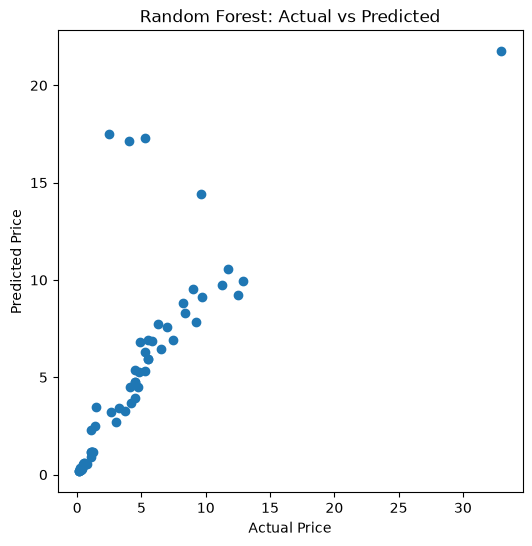

In [44]:
plt.figure(figsize=(6,6))

plt.scatter(target_test, target_pred_rf)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Random Forest: Actual vs Predicted")

plt.show()

## 13. Support Vector Regressor (SVR):-

In [45]:
svr = SVR(kernel="rbf")

svr.fit(features_train_scaled,target_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


### 13.1 Predict

In [46]:
target_pred_svr = svr.predict(features_test_scaled)

### 13.2 Evaluation

In [47]:
mae_svr = mean_absolute_error(target_test, target_pred_svr)
mse_svr = mean_squared_error(target_test, target_pred_svr)
rmse_svr = np.sqrt(mse_svr)
r2_svr = r2_score(target_test, target_pred_svr)

print("MAE :", mae_svr)
print("MSE :", mse_svr)
print("RMSE :", rmse_svr)
print("R2 Score :", r2_svr)

MAE : 1.2444305689371304
MSE : 10.302799255337382
RMSE : 3.2097973854026023
R2 Score : 0.6002524179320186


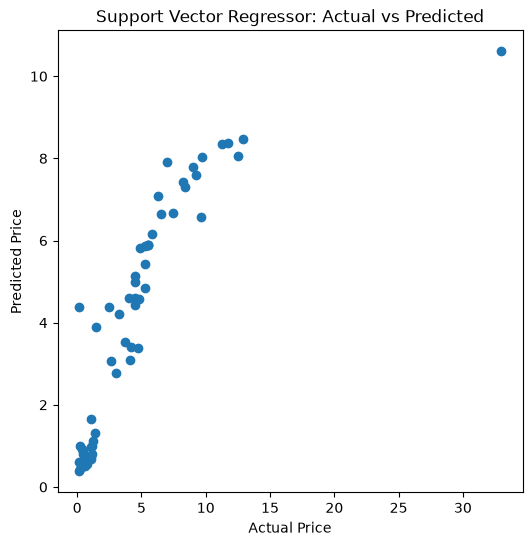

In [48]:
plt.figure(figsize=(6,6))

plt.scatter(target_test, target_pred_svr)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Support Vector Regressor: Actual vs Predicted")

plt.show()

## 14. Model Comparison

The performance of different regression models is compared using evaluation metrics.

In [49]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Support Vector Regressor"
    ],
    "R2 Score": [
        r2,
        r2_dt,
        r2_rf,
        r2_svr
    ],
    "MAE": [
        mae,
        mae_dt,
        mae_rf,
        mae_svr
    ],
    "RMSE": [
        rmse,
        rmse_dt,
        rmse_rf,
        rmse_svr
    ]
})

comparison.sort_values(by="R2 Score", ascending=False)

,Model,R2 Score,MAE,RMSE
1,Decision Tree,0.827975,1.108500,2.105621
0,Linear Regression,0.752723,1.472546,2.524505
3,Support Vector Regressor,0.600252,1.244431,3.209797
2,Random Forest,0.522152,1.465723,3.509374


## 15. Conclusion

- The dataset was cleaned and preprocessed successfully.
- Feature engineering was performed by creating the Car_Age feature and encoding categorical variables.
- Different regression models were trained and evaluated.
- Decision Tree Regressor achieved the highest R2 Score (≈0.83), making it the best-performing model for this dataset.
- The trained model can be used to estimate the selling price of used cars based on their features.